In [2]:
import pandas as pd
import pyarrow as pa
import os
import autoslo.utils.paths as pu
from tqdm.auto import tqdm

# Find the number of queries per day in each redset instance
instance_counts = {}
for id in tqdm(range(200)):
    path = pu.get_redset_raw_data(cluster_id =id)
    df = pd.read_parquet(path, engine='pyarrow', columns=['arrival_timestamp'])
    df['date'] = pd.to_datetime(df['arrival_timestamp'], unit='s').dt.date
    counts = df['date'].value_counts().sort_index()
    instance_counts[id] = counts



  0%|          | 0/200 [00:00<?, ?it/s]

In [8]:
# For each element in instance_counts, count the number of days with nonzero count
summary_counts = {}
for id, counts in instance_counts.items():
    nonzero_days = (counts > 0).sum()
    total_queries = counts.sum()
    summary_counts[id] = (nonzero_days, total_queries)

summary_df = pd.DataFrame.from_dict(summary_counts, orient='index', columns=['nonzero_days', 'total_queries'])
summary_df.index.name = 'cluster_id'
summary_df = summary_df.reset_index().sort_values(by=['nonzero_days', 'total_queries'], ascending=False)
summary_df.head(10)

,cluster_id,nonzero_days,total_queries
109,109,93,37224155
100,100,93,20673518
51,51,93,13524597
31,31,93,9048312
6,6,92,12952859
156,156,92,7095403
98,98,92,6830592
0,0,92,6471671
133,133,92,6005301
185,185,92,5612854


In [55]:
# Read in the whole parquet file for the top cluster
top_cluster_id = summary_df.iloc[1]['cluster_id']
top_cluster_path = pu.get_redset_raw_data(cluster_id=top_cluster_id)
top_cluster_df = pd.read_parquet(top_cluster_path, engine='pyarrow')

top_cluster_df.head()

,instance_id,cluster_size,user_id,database_id,query_id,arrival_timestamp,compile_duration_ms,queue_duration_ms,execution_duration_ms,feature_fingerprint,was_aborted,was_cached,cache_source_query_id,query_type,num_permanent_tables_accessed,num_external_tables_accessed,num_system_tables_accessed,read_table_ids,write_table_ids,mbytes_scanned,mbytes_spilled,num_joins,num_scans,num_aggregations
0,100,2.0,0,0,2188892,2024-02-29 23:59:59.970648,203.0,0,210,8cdab5d15ebfc712477b948c00868827ff4f0e48bdd3d35ee89d3d8b3a445c51,0,0,NaN,insert,3.0,0.0,0.0,223904,1,404.0,0.0,0,1,2
1,100,2.0,0,0,1237252,2024-03-01 00:00:03.298975,35.0,0,39,39216531283ae51e71f92a525d81517812f9f8f29c5921ce3ffd2c4b1a54d823,0,0,NaN,update,2.0,0.0,0.0,"2,223904",2,90.0,0.0,3,4,2
2,100,2.0,0,0,1995576,2024-03-01 00:00:03.951715,5.0,0,6,4d7e21fd820ae36e41cc2ffe112e98a80c43819b7fe9af7a7e371b0d15dad31c,0,0,NaN,vacuum,1.0,0.0,0.0,1,None,8.0,0.0,0,1,2
3,100,2.0,0,0,1458377,2024-03-01 00:00:05.638287,0.0,0,1,4d7e21fd820ae36e41cc2ffe112e98a80c43819b7fe9af7a7e371b0d15dad31c,0,0,NaN,vacuum,1.0,0.0,0.0,None,None,0.0,0.0,0,0,0
4,100,2.0,0,0,2032890,2024-03-01 00:00:05.891979,115.0,0,115,4d7e21fd820ae36e41cc2ffe112e98a80c43819b7fe9af7a7e371b0d15dad31c,0,0,NaN,vacuum,1.0,0.0,0.0,1,None,4.0,0.0,0,1,3


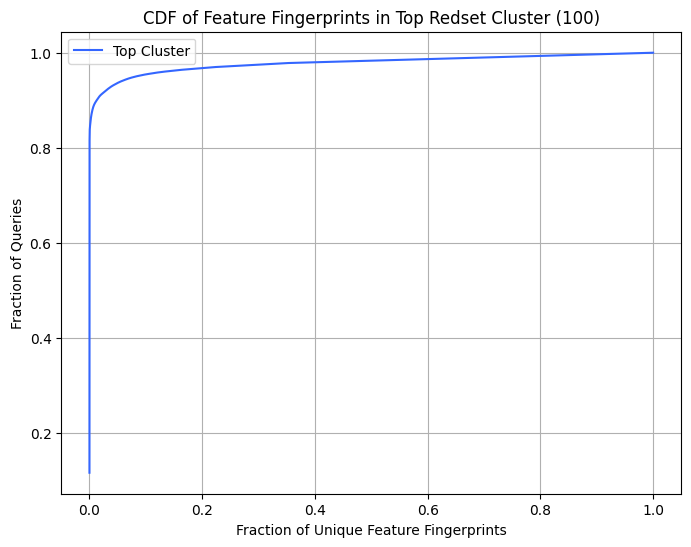

In [56]:
from autoslo.utils.colors import Palette
import matplotlib.pyplot as plt

# Plot a CDF where the x axis is fraction of unique feature_fingerprints and the y axis is fraction of queries
plt.figure(figsize=(8,6))
feature_fingerprint_counts = top_cluster_df['feature_fingerprint'].value_counts().sort_values(ascending=False)
feature_fingerprint_cdf = feature_fingerprint_counts.cumsum() / feature_fingerprint_counts.sum()
feature_fingerprint_cdf = feature_fingerprint_cdf.reset_index(drop=True)
feature_fingerprint_cdf = feature_fingerprint_cdf / feature_fingerprint_cdf.max()
plt.plot(feature_fingerprint_cdf.index / len(feature_fingerprint_cdf), feature_fingerprint_cdf.values, label='Top Cluster', color=Palette.dark_blue)
plt.xlabel('Fraction of Unique Feature Fingerprints')
plt.ylabel('Fraction of Queries')
plt.title(f'CDF of Feature Fingerprints in Top Redset Cluster ({top_cluster_id})')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:

unique_query_types = top_cluster_df['query_type'].unique()


# Create a df where each row is a feature fingerprint, each column is a query type, and the value is the count
for qt in unique_query_types:
    col_name = f'count_{qt}'
    top_cluster_df[col_name] = (top_cluster_df['query_type'] == qt).astype(int)   
cols = ['feature_fingerprint'] + [f'count_{qt}' for qt in unique_query_types]
feature_fingerprint_summary = top_cluster_df[cols].groupby('feature_fingerprint').sum().reset_index()
feature_fingerprint_summary.head()
    

,feature_fingerprint,count_insert,count_update,count_vacuum,count_copy,count_delete,count_other,count_select,count_ctas,count_analyze
0,000006976574b97162279f0c94d824cea596652a49469a5626bc906b6d47ac80,0,0,0,0,0,0,1,0,0
1,00000963f73e06ce631af9ff43b5eff2163e6b1665a7c711d3d358cb0f0baf6f,1,0,0,0,0,0,0,0,0
2,00004925f5dab2c5addc7d0eb482f4592b91bb643d8d37eb593ef9f8c872b740,0,0,0,0,0,0,0,0,2
3,00005f7113b200b2973461b7c78255874fddb4162bec2b2654ac981baac0cb5b,0,0,0,0,1,0,0,0,0
4,0000900874e6747c89182d4565904099611360badb778b6c24d5c69fc1c24053,0,0,0,0,1,0,0,0,0


In [58]:
# Create a column that includes a sorted set of the query types in that row with nonzero count  
feature_fingerprint_summary['seen_types'] = (
    feature_fingerprint_summary.apply(
        lambda row: tuple(sorted([qt for qt in unique_query_types if row[f'count_{qt}'] > 0])), axis=1
    )
)

In [61]:
feature_fingerprint_summary['count'] = feature_fingerprint_summary[ [f'count_{qt}' for qt in unique_query_types] ].sum(axis=1)

In [62]:
feature_fingerprint_summary.groupby('seen_types')['count'].sum().reset_index().sort_values(by='count', ascending=False)

,seen_types,count
4,"(insert,)",8339363
5,"(select,)",3997639
3,"(delete,)",3259690
2,"(ctas,)",2114363
1,"(analyze, copy, other, vacuum)",1494803
0,"(analyze,)",922186
6,"(update,)",539063


In [60]:
top_cluster_df.shape

(20673518, 33)

/tmp/ipykernel_160794/1281331115.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_df['execution_duration_s'] = top_10_df['execution_duration_ms'] / 1000.0


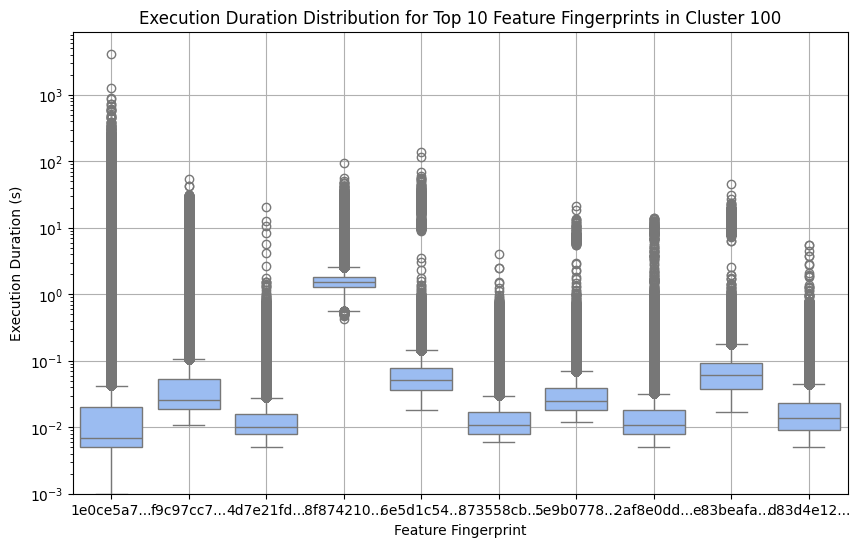

In [64]:
# For the top 10 feature_fingerprints, plot their latency distributions in a violin plot
top_10_fingerprints = feature_fingerprint_summary.sort_values(by='count', ascending=False).head(10)['feature_fingerprint'].tolist()
top_10_df = top_cluster_df[top_cluster_df['feature_fingerprint'].isin(top_10_fingerprints)]

plt.figure(figsize=(10,6))
import seaborn as sns
# Use the colors from our palette and don't print the boxplot inside the violin plot. 
# Normalize all violins to same width.
top_10_df['execution_duration_s'] = top_10_df['execution_duration_ms'] / 1000.0
sns.boxplot(x='feature_fingerprint', y='execution_duration_s', data=top_10_df, color=Palette.light_blue)
plt.xlabel('Feature Fingerprint')
plt.ylabel('Execution Duration (s)')
plt.title(f'Execution Duration Distribution for Top 10 Feature Fingerprints in Cluster {top_cluster_id}')
plt.yscale('log')
plt.ylim(bottom=0.001)
plt.grid(True)

# Only show the first 8 characters of the feature_fingerprint for readability
plt.xticks(ticks=range(10), labels=[f"{str(fp)[:8]}..." for fp in top_10_fingerprints])

plt.show()

In [68]:
feature_fingerprint_summary[feature_fingerprint_summary['feature_fingerprint'].isin(top_10_fingerprints)].sort_values(by='count', ascending=False)

,feature_fingerprint,count_insert,count_update,count_vacuum,count_copy,count_delete,count_other,count_select,count_ctas,count_analyze,seen_types,count
81082,1e0ce5a743fc489aa700dd77d566337e6872dc878cc4b7357c775ab59e95e923,2405765,0,0,0,0,0,0,0,0,"(insert,)",2405765
675476,f9c97cc7b016c1d24c69aacc225266a08ba229e68d9f631843f15d1c97aed766,1584439,0,0,0,0,0,0,0,0,"(insert,)",1584439
209509,4d7e21fd820ae36e41cc2ffe112e98a80c43819b7fe9af7a7e371b0d15dad31c,0,0,29860,272515,0,209,0,0,1192219,"(analyze, copy, other, vacuum)",1494803
387701,8f87421055eb3931b803e88688fd94956c78f0f498c047c82962e6d5f1c5d73c,0,0,0,0,0,0,1038742,0,0,"(select,)",1038742
298124,6e5d1c54684027f5b890bac0abe82fa54fa4994e10d984a32914b789a746eeb2,0,0,0,0,0,0,1038646,0,0,"(select,)",1038646
365120,873558cb22ad92acab65878c6a7a8d02e2c5866cf5d1f560639d4ba85086d7b5,0,0,0,0,0,0,0,0,828025,"(analyze,)",828025
255468,5e9b07784b05564c8ac4a05555d29bf76085a4fa07c3941be904b7b3aac8c3d0,706287,0,0,0,0,0,0,0,0,"(insert,)",706287
116058,2af8e0ddb9879ba8112b200fc9f2a5f24ca7ce473cf66a912b95ccc5433c6b28,0,0,0,0,468371,0,0,0,0,"(delete,)",468371
627997,e83beafa5276b79085d77bb911e645086a757167faf24428b8569306b7f25695,0,0,0,0,0,0,467208,0,0,"(select,)",467208
584552,d83d4e121912f27f123b26c648d26e6b61064326f924ab2ea95418335fe7debe,451149,0,0,0,0,0,0,0,0,"(insert,)",451149


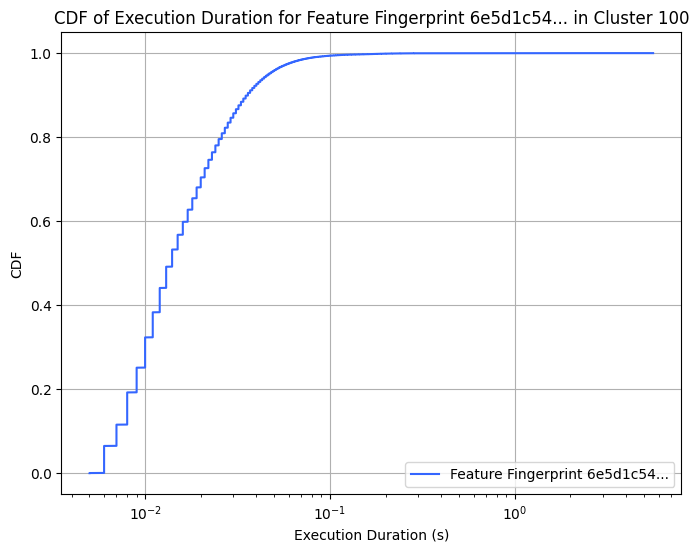

In [70]:
# Plot a cdf of the latency of the 5th feature_fingerprint
top_fp_df_1 = top_10_df[top_10_df['feature_fingerprint'] == top_10_fingerprints[4]].copy()
top_fp_df_1 = top_fp_df_1.sort_values(by='execution_duration_s').reset_index(drop=True)
top_fp_df_1['cdf'] = (top_fp_df_1.index + 1) / len(top_fp_df_1)   
plt.figure(figsize=(8,6))
plt.plot(top_fp_df_1['execution_duration_s'], top_fp_df_1['cdf'], label=f'Feature Fingerprint {str(top_10_fingerprints[4])[:8]}...', color=Palette.dark_blue)
plt.xlabel('Execution Duration (s)')
plt.ylabel('CDF')
plt.title(f'CDF of Execution Duration for Feature Fingerprint {str(top_10_fingerprints[4])[:8]}... in Cluster {top_cluster_id}')
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [75]:
top_fp_df_1.describe()

,instance_id,cluster_size,user_id,database_id,query_id,arrival_timestamp,compile_duration_ms,queue_duration_ms,execution_duration_ms,was_aborted,was_cached,cache_source_query_id,num_permanent_tables_accessed,num_external_tables_accessed,num_system_tables_accessed,mbytes_scanned,mbytes_spilled,num_joins,num_scans,num_aggregations,count_insert,count_update,count_vacuum,count_copy,count_delete,count_other,count_select,count_ctas,count_analyze,execution_duration_s,cdf
count,1038646.0,1038646.0,1038646.0,1038646.0,1.038646e+06,1038646,1.038646e+06,1038646.0,1.038646e+06,1038646.0,1038646.0,0.0,1038646.0,1038646.0,1038646.0,1.038646e+06,1.038646e+06,1038646.0,1038646.0,1.038646e+06,1038646.0,1038646.0,1038646.0,1038646.0,1038646.0,1038646.0,1038646.0,1038646.0,1038646.0,1.038646e+06,1.038646e+06
mean,100.0,2.0,0.0,0.0,1.068231e+07,2024-05-07 09:27:29.741690,1.249532e+01,0.0,1.916721e+01,0.0,0.0,NaN,1.0,0.0,0.0,1.683923e-03,7.702336e-06,0.0,1.0,1.996665e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.916721e-02,5.000005e-01
min,100.0,2.0,0.0,0.0,1.230400e+04,2024-04-15 03:56:45.546589,3.000000e+00,0.0,5.000000e+00,0.0,0.0,NaN,1.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,1.0,1.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.000000e-03,9.627919e-07
25%,100.0,2.0,0.0,0.0,5.703002e+06,2024-04-27 18:55:26.843175,6.000000e+00,0.0,9.000000e+00,0.0,0.0,NaN,1.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,1.0,2.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.000000e-03,2.500007e-01
50%,100.0,2.0,0.0,0.0,1.074910e+07,2024-05-07 02:00:43.753438,8.000000e+00,0.0,1.400000e+01,0.0,0.0,NaN,1.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,1.0,2.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.400000e-02,5.000005e-01
75%,100.0,2.0,0.0,0.0,1.567638e+07,2024-05-16 18:48:20.236559,1.300000e+01,0.0,2.300000e+01,0.0,0.0,NaN,1.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,1.0,2.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.300000e-02,7.500002e-01
max,100.0,2.0,0.0,0.0,2.067350e+07,2024-05-30 23:59:55.634665,5.597000e+03,0.0,5.605000e+03,0.0,0.0,NaN,1.0,0.0,0.0,1.500000e+01,4.000000e+00,0.0,1.0,2.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.605000e+00,1.000000e+00
std,0.0,0.0,0.0,0.0,5.797736e+06,NaN,1.764450e+01,0.0,2.256539e+01,0.0,0.0,NaN,0.0,0.0,0.0,1.261547e-01,4.602324e-03,0.0,0.0,5.765407e-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.256539e-02,2.886753e-01
